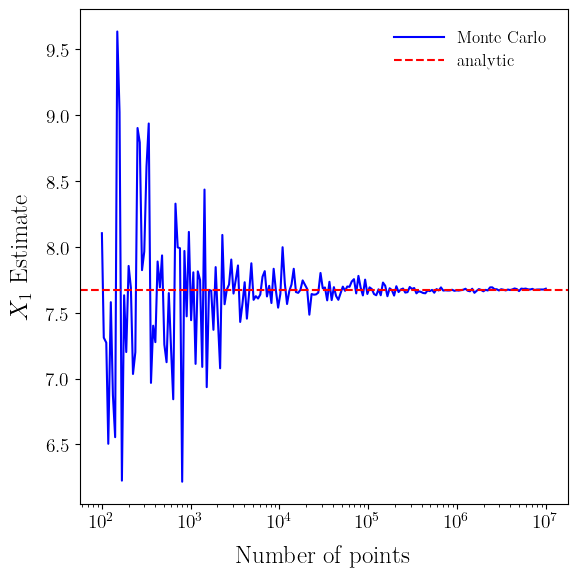

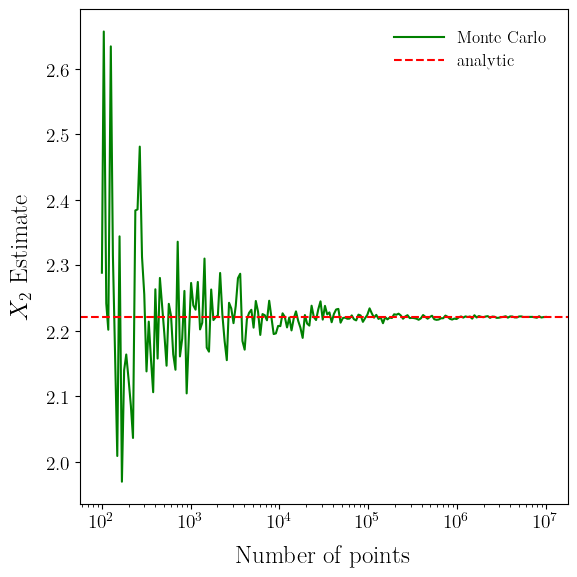

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams


#############################################################################
#                            Parametry simulace                             #

number_points = np.logspace(2, 7, num=200, base=10).astype(int)
analytical_x1 = 7.674686725476918
analytical_x2 = 2.221441469079183

def f_x1(x):
    return x * (x + np.pi)**2 * np.sin(x)

def f_x2(x):
    return 1 / (1 + (x - 5)**4)

sigma_x2 = 2

#############################################################################


#############################################################################
#                                 Vzhled grafů                              #

legend_frame = False
grid = False

X_label = 'Number of points'
Y1_label = r'$X_1$ Estimate'
Y2_label = r'$X_2$ Estimate'

SMALL_SIZE = 14
MEDIUM_SIZE = 18
BIGGER_SIZE = 24
LEGEND_SIZE = 12

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{lmodern}',
    'font.family': 'serif',
    'font.serif': ['Latin Modern Roman'],
    'axes.titlepad': 10,
    'axes.labelpad': 10,
    'legend.fancybox': False,
    'legend.edgecolor': "#000000",
    'figure.autolayout': True,
    'legend.handlelength': 3,
    'legend.framealpha': 1,
    'legend.borderpad': 0.8
})

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=MEDIUM_SIZE)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=LEGEND_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)

#############################################################################


#############################################################################
#                                    Řešení                                 #

# X1 
estimates_x1 = []
for n in number_points:
    x = np.random.normal(loc=0, scale=1/np.sqrt(2), size=n)
    estimates_x1.append(np.mean(f_x1(x)) * np.sqrt(np.pi))

# X2
estimates_x2 = []

for n in number_points:
    x = np.random.normal(loc=5, scale=sigma_x2, size=n)
    
    f_values = f_x2(x)
    normal_distrubition = (1/(sigma_x2 * np.sqrt(2*np.pi))) * np.exp(-(x - 5)**2/(2*sigma_x2**2))
    values = f_values / normal_distrubition
    
    estimates_x2.append(np.mean(values))

# Graf X1
plt.figure(figsize=(6,6))
plt.xscale('log')
plt.plot(number_points, estimates_x1, 'b-', label='Monte Carlo')
plt.axhline(analytical_x1, color='r', linestyle='--', label='analytic')
plt.xlabel(X_label)
plt.ylabel(Y1_label)
plt.legend(frameon=legend_frame)
plt.grid(grid)
plt.tight_layout()
plt.show()

# Graf X2
plt.figure(figsize=(6,6))
plt.xscale('log')
plt.plot(number_points, estimates_x2, 'g-', label='Monte Carlo')
plt.axhline(analytical_x2, color='r', linestyle='--', label='analytic')
plt.xlabel(X_label)
plt.ylabel(Y2_label)
plt.legend(frameon=legend_frame)
plt.grid(grid)
plt.tight_layout()
plt.show()